### Test JaxTracer on Hydro Turbulence - Trace at depth and save the ray state

Import Libs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

#add path
sys.path.insert(0, '../')     # import path/to/sloth

import src.core.config as config
config.jax_init(force_device = "gpu", enable_x64= True)

import core.beam as beam_initialiser
import core.domain as d
import core.propagator as p
import processing.diagnostics as diag

import utils.handle_filetypes as utilIO
import jax.numpy as jnp

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: /rds/general/user/sm13118/home/dev/SLOTH/src

Disabling python multi-threading...
Initialising jax...


Default jax backend: gpu
Available devices: [CudaDevice(id=0)]


<module 'processing.diagnostics' from '/rds/general/user/sm13118/home/dev/SLOTH/src/processing/diagnostics.py'>

Import domain

In [2]:
base_folder = "/rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC"
path_to_file = "/xyz11_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0193"
filename = base_folder+path_to_file
#  -----------------

#load hdf
ne, dims, spacing = utilIO.hdf_readin(filename, prefer_ye=True, force_override=True, verbose=True)

print(ne.shape)

multi_x = 0
multi_y = 0
multi_z = 3

ne = np.concatenate([ne] * (multi_x + 1), axis=0)
ne = np.concatenate([ne] * (multi_y + 1), axis=1)
ne = np.concatenate([ne] * (multi_z + 1), axis=2)

dims = ne.shape

extent_x = ((dims[0]*spacing[0].v)/2) * 1e-2
extent_y = ((dims[1]*spacing[1].v)/2) * 1e-2
extent_z = ((dims[2]*spacing[2].v)/2) * 1e-2

lengths = 2 * jnp.array([extent_x, extent_y, extent_z], dtype = jnp.float32)
print(lengths)

ne_x = np.linspace(-extent_x,extent_x, dims[0])
ne_y = np.linspace(-extent_y,extent_y, dims[1])
ne_z = np.linspace(-extent_z,extent_z, dims[2])

print(f'extent x: {extent_x}')
print(f'extent y: {extent_y}')
print(f'extent z: {extent_z}')

print(f'dims x: {dims[0]}')
print(f'dims y: {dims[1]}')
print(f'dims z: {dims[2]}')

print("\n\n")

# is this baseline not decreasing after each run? - testing manually deleting objects first
# baseline = memory_report()['used_raw']
probing_direction = 'z'

Np = 1e6
domain = d.ScalarDomain(lengths, dims, leeway_factor = 3, ne_type = "import", probing_direction = probing_direction, Np = Np, ne = ne.v*1e6)

del ne_x
del ne_y
del ne_z
del ne

yt : [INFO     ] 2026-03-26 11:22:23,122 Parameters: current_time              = 1.6168791515097758e-07
yt : [INFO     ] 2026-03-26 11:22:23,122 Parameters: domain_dimensions         = [1200  750  500]
yt : [INFO     ] 2026-03-26 11:22:23,123 Parameters: domain_left_edge          = [-0.1  0.   0. ]
yt : [INFO     ] 2026-03-26 11:22:23,123 Parameters: domain_right_edge         = [1.1  0.75 0.5 ]
yt : [INFO     ] 2026-03-26 11:22:23,123 Parameters: cosmological_simulation   = 0


[hdf_readin] Loaded: /rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC/xyz11_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0193
[hdf_readin] has_ye=True (prefer_ye=True)
[hdf_readin] max_level=0
[hdf_readin] dims=(1200, 750, 500)
[hdf_readin] spacing=[unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length')]
(1200, 750, 500)
[0.012  0.0075 0.02  ]
extent x: 0.006000000000000001
extent y: 0.00375
extent z: 0.01
dims x: 1200
dims y: 750
dims z: 2000



Predicted size in memory of domain: 6.705522537231445 GB

Memory prior to domain creation:
 - total : 44.98828125 GB
 - free  : 44.149658203125 GB
 - used  : 858.75 MB

Est. ray size in memory: 2.0563602447509766 GB
Est. domain memory limit: 40.23313522338867 GB
 --> inc. +200.0% variance margin
Total estimated maximum: 46.4022159576416 GB

E

Tracing using JaxTracer

1.132984700338544e+27


np.float64(0.01)

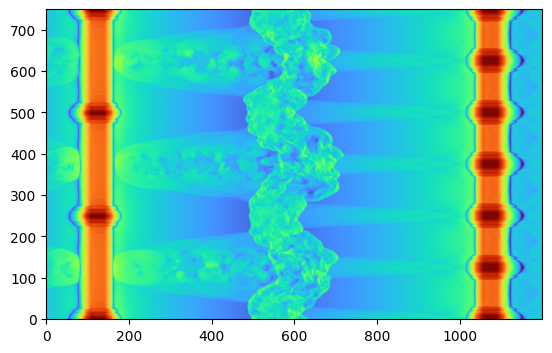

In [3]:
print(domain.ne.T.max())
plt.imshow(domain.ne[:,:,20].T, origin="lower",cmap='turbo', norm="log")
extent_z

In [5]:
# define beam parameters
lwl            =  1064e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.1e-3
beam_type      =  "rectangular"


# --- trace and save Jones vector every 200 µm up to 1 mm ---
result = p.trace_and_save_depths(
    (beam_size, divergence, ne_extent, probing_direction, beam_type, False), domain,
    step       = 600e-6,            # save cadence (m)
    depth_max  = 19.9e-3,              # maximum depth (m)
    output_path= "depth_saves.pkl", # set to None to skip file write
    lwl        = lwl,
    jones_components = [0, 3],  # save jones component (x: 0, theta: 1, y: 2, phi: 3)
    verbose    = True,
)

# result['depth_saves']  – 1-D array of save depths (m)
# result['jvec']         – list of (2, Np) arrays at each depth
# result['jones_components'] – [0, 2]  (rows saved)

depth_mm = result['depth_saves'] * 1e3


trace_and_save_depths: saving at 34 depth(s) from 0 to 19.9 mm (step = 600 µm, probing direction = 'z', jones_components = [0, 3]).
True
True
True
trace_and_save_depths: results saved to 'depth_saves.pkl'.


Text(0, 0.5, '$\\phi$ (mrad)')

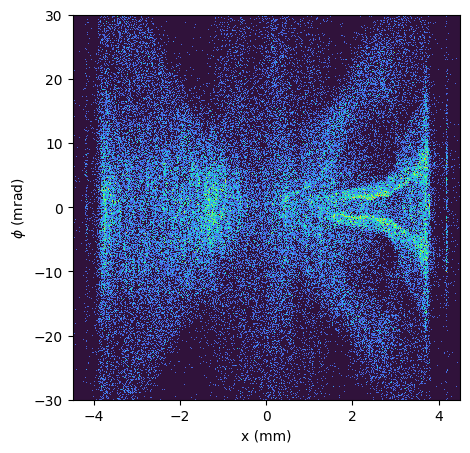

In [55]:
import matplotlib.colors as mcolors

def lens_cutoff_1d(x, phi, *, L=400, R=25):
    """
    1D lens cutoff using only x and phi information.
    """
    x = np.asarray(x, dtype=float)
    phi = np.asarray(phi, dtype=float)

    x_lens = x + L * np.tan(phi)
    mask = np.abs(x_lens) <= R
    
    return mask, x_lens

def ccd_cutoff_1d(phi, *, phi_max=None, phi_min=None):
    """
    Standalone CCD cutoff in angle space.
    Keeps only rays whose measured angle lies within the CCD range.
    """
    phi = np.asarray(phi, dtype=float)

    if phi_max is None and phi_min is None:
        return np.isfinite(phi)

    if phi_max is not None and phi_min is None:
        phi_min = -phi_max

    mask = np.isfinite(phi)

    if phi_min is not None:
        mask &= (phi >= phi_min)
    if phi_max is not None:
        mask &= (phi <= phi_max)
    return mask
# --------------------------

x_mm = np.asarray(result["jvec"][i][0], dtype=float) * 1e3
phi_mrad = np.asarray(result["jvec"][i][1], dtype=float) * 1e3

# remove NaNs first
good = np.isfinite(x_mm) & np.isfinite(phi_mrad)
x_mm = x_mm[good]
phi_mrad = phi_mrad[good]

#  -----------------

lens_cutoff = True
ccd_cutoff  = True

if lens_cutoff:
    # optional lens cutoff
    phi_rad = phi_mrad * 1e-3
    mask_lens, _ = lens_cutoff_1d(x_mm, phi_rad, L=400, R=25)
    x_mm = x_mm[mask_lens]
    phi_mrad = phi_mrad[mask_lens]

if ccd_cutoff:
    mask_ccd = ccd_cutoff_1d(phi_mrad, phi_max=35.0)
    phi_mrad = phi_mrad[mask_ccd]
    x_mm = x_mm[mask_ccd]

# -------------------------------

nbins_x=3448
nbins_y=2574

fig, ax1 = plt.subplots(1,1, figsize = (5,5))

_,_,_,img1 = ax1.hist2d(x_mm, phi_mrad, bins=(nbins_x, nbins_y), cmap ="turbo", norm=mcolors.PowerNorm(0.8));

ax1.set_xlim(-4.5, 4.5)
ax1.set_xticks([-4, -2, 0, 2, 4])
ax1.set_aspect('auto')

ax1.set_xlabel(r"x (mm)")
ax1.set_ylim(-30,30)
ax1.set_yticks([-30, -20,-10,0,10,20,30])
ax1.grid(False)
ax1.set_ylabel(r"$\phi$ (mrad)")

In [86]:
import pandas as pd

def moments_from_curve(phi, intensity, phi_min=None, phi_max=None, eps=1e-12, renormalize=True):
    """
    Moments from definitions using numerical quadrature.
    intensity can be '0..1 normalized' (peak) or already a PDF; we normalize by area if renormalize=True.
    """
    phi = np.asarray(phi, dtype=float)
    w   = np.asarray(intensity, dtype=float)

    if (phi_min is not None) or (phi_max is not None):
        lo = -np.inf if phi_min is None else phi_min
        hi =  np.inf if phi_max is None else phi_max
        m = (phi >= lo) & (phi <= hi)
        phi, w = phi[m], w[m]

    idx = np.argsort(phi)
    phi, w = phi[idx], np.maximum(w[idx], 0.0)

    area = np.trapezoid(w, phi)
    if area < eps:
        return dict(area=area, mean=np.nan, var=np.nan, std=np.nan,
                    skew=np.nan, kurtosis=np.nan, excess_kurtosis=np.nan)

    p = w / area if renormalize else w
    if not renormalize:
        # still report the area so you can check if it's ~1
        pass
    else:
        area = 1.0

    mu = np.trapezoid(phi * p, phi)
    d  = phi - mu

    m2 = np.trapezoid((d**2) * p, phi)
    std = np.sqrt(max(m2, 0.0))

    if std < eps:
        return dict(area=area, mean=mu, var=m2, std=std,
                    skew=np.nan, kurtosis=np.nan, excess_kurtosis=np.nan)

    m3 = np.trapezoid((d**3) * p, phi)
    m4 = np.trapezoid((d**4) * p, phi)

    skew = m3 / (std**3)
    kurt = m4 / (std**4)      # Gaussian -> 3
    ex_kurt = kurt - 3.0      # Gaussian -> 0

    return dict(area=area, mean=mu, var=m2, std=std,
                skew=skew, kurtosis=kurt, excess_kurtosis=ex_kurt)

def cdf_quantile_width(phi, intensity, qlo=0.10, qhi=0.90, phi_min=None, phi_max=None, eps=1e-12):
    """
    Robust width from CDF quantiles using trapezoidal cumulative integration.
    Always normalizes by area to build a CDF (definition).
    """
    phi = np.asarray(phi, dtype=float)
    w   = np.asarray(intensity, dtype=float)

    if (phi_min is not None) or (phi_max is not None):
        lo = -np.inf if phi_min is None else phi_min
        hi =  np.inf if phi_max is None else phi_max
        m = (phi >= lo) & (phi <= hi)
        phi, w = phi[m], w[m]

    idx = np.argsort(phi)
    phi, w = phi[idx], np.maximum(w[idx], 0.0)

    area = np.trapezoid(w, phi)
    if area < eps:
        return dict(W=np.nan, qlo_phi=np.nan, qhi_phi=np.nan, area=area)

    dphi = np.diff(phi)
    trap = 0.5 * (w[:-1] + w[1:]) * dphi
    cdf = np.concatenate([[0.0], np.cumsum(trap)]) / area
    cdf[-1] = 1.0

    phi_lo = np.interp(qlo, cdf, phi)
    phi_hi = np.interp(qhi, cdf, phi)
    return dict(W=phi_hi - phi_lo, qlo_phi=phi_lo, qhi_phi=phi_hi, area=area)

def sigma_equiv_10_90(width_10_90):
    # Gaussian: W10-90 = 2.5631031310892007 * sigma
    return width_10_90 / 2.5631031310892007


def phi_distribution_from_roi(
    x_mm,
    phi_mrad,
    x_roi_mm=(-1.0, 1.0),
    x_range_mm=None,
    phi_range_mrad=None,
    nx=nbins_x,
    nphi=nbins_y
):
    x_mm = np.asarray(x_mm, dtype=float)
    phi_mrad = np.asarray(phi_mrad, dtype=float)

    good = np.isfinite(x_mm) & np.isfinite(phi_mrad)
    x_mm = x_mm[good]
    phi_mrad = phi_mrad[good]

    if x_mm.size == 0 or phi_mrad.size == 0:
        return None, None, None, None, None

    if x_range_mm is None:
        dx = x_mm.max() - x_mm.min()
        x_pad = 0.02 * dx if dx > 0 else 0.1
        x_range_mm = (x_mm.min() - x_pad, x_mm.max() + x_pad)

    if phi_range_mrad is None:
        dp = phi_mrad.max() - phi_mrad.min()
        p_pad = 0.02 * dp if dp > 0 else 0.1
        phi_range_mrad = (phi_mrad.min() - p_pad, phi_mrad.max() + p_pad)

    H, x_edges, phi_edges = np.histogram2d(
        x_mm,
        phi_mrad,
        bins=(nx, nphi),
        range=[x_range_mm, phi_range_mrad]
    )

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])

    x_mask = (x_centers >= x_roi_mm[0]) & (x_centers <= x_roi_mm[1])
    phi_dist = H[x_mask, :].sum(axis=0)

    return phi_centers, phi_dist, x_centers, H, x_mask


def moments_vs_depth_from_hist_roi_1dcut(
    result,
    x_roi_mm=(-1.0, 1.0),
    depth_roi_mm=None,
    phi_window=None,
    x_range_mm=None,
    phi_range_mrad=None,
    nx=nbins_x,
    nphi=nbins_y,
    qlo=0.10,
    qhi=0.90,
    eps=1e-12,
    apply_lens=False,
    apply_ccd=False,
    L_mm=400,
    R_mm=25,
):
    depths_mm = np.asarray(result["depth_saves"], dtype=float) * 1e3
    phi_min, phi_max = (None, None) if phi_window is None else phi_window

    rows = []

    for i, depth_mm in enumerate(depths_mm):

        if depth_roi_mm is not None:
            zmin, zmax = depth_roi_mm
            if not (zmin <= depth_mm <= zmax):
                continue

        x_mm = np.asarray(result["jvec"][i][0], dtype=float) * 1e3
        phi_mrad = np.asarray(result["jvec"][i][1], dtype=float) * 1e3
        
        good = np.isfinite(x_mm) & np.isfinite(phi_mrad)
        x_mm = x_mm[good]
        phi_mrad = phi_mrad[good]
        
        n_before = x_mm.size
            
        if apply_lens:
            phi_rad = phi_mrad * 1e-3
            mask_lens, x_lens_mm = lens_cutoff_1d(x_mm, phi_rad, L=L_mm, R=R_mm)
            x_mm = x_mm[mask_lens]
            phi_mrad = phi_mrad[mask_lens]
            
        if apply_ccd:
            mask_ccd = ccd_cutoff_1d(phi_mrad, phi_max=35.0)
            phi_mrad = phi_mrad[mask_ccd]
            x_mm = x_mm[mask_ccd]

        n_after = x_mm.size
        
        out = phi_distribution_from_roi(
            x_mm,
            phi_mrad,
            x_roi_mm=x_roi_mm,
            x_range_mm=x_range_mm,
            phi_range_mrad=phi_range_mrad,
            nx=nx,
            nphi=nphi
        )

        phi_centers, phi_dist, x_centers, H, x_mask = out

        if phi_centers is None or np.sum(phi_dist) <= 0:
            rows.append({
                "depth_mm": depth_mm,
                "n_before_lens": n_before,
                "n_after_lens": round(n_after/n_before * 100),
                "mean_mrad": np.nan,
                "var_mrad2": np.nan,
                "std_mrad": np.nan,
                "skew": np.nan,
                "kurtosis": np.nan,
                "excess_kurtosis": np.nan,
                f"W{int(100*qlo)}_{int(100*qhi)}_mrad": np.nan,
                "sigma_eq_10_90_mrad": np.nan,
            })
            continue

        m = moments_from_curve(
            phi_centers,
            phi_dist,
            phi_min=phi_min,
            phi_max=phi_max,
            eps=eps,
            renormalize=True
        )

        q = cdf_quantile_width(
            phi_centers,
            phi_dist,
            qlo=qlo,
            qhi=qhi,
            phi_min=phi_min,
            phi_max=phi_max,
            eps=eps
        )

        rows.append({
            "depth_mm": depth_mm,
            "n_before_lens": n_before,
            "n_after_lens": round(n_after/n_before * 100),
            "mean_mrad": m["mean"],
            "var_mrad2": m["var"],
            "std_mrad": m["std"],
            "skew": m["skew"],
            "kurtosis": m["kurtosis"],
            "excess_kurtosis": m["excess_kurtosis"],
            f"W{int(100*qlo)}_{int(100*qhi)}_mrad": q["W"],
            "sigma_eq_10_90_mrad": sigma_equiv_10_90(q["W"]) if np.isfinite(q["W"]) else np.nan,
        })

    return pd.DataFrame(rows).sort_values("depth_mm").reset_index(drop=True)

In [87]:
df_syn = moments_vs_depth_from_hist_roi_1dcut(
    result,
    x_roi_mm=(-0.75, 0.75),
    apply_lens=True,
    apply_ccd=True,
    L_mm=400,
    R_mm=25
)

print(df_syn)

     depth_mm  n_before_lens  n_after_lens  mean_mrad   var_mrad2   std_mrad  \
0    0.000000        1000000           100   0.000195    0.005000   0.070714   
1    0.603030        1000000            96   0.008740    5.354821   2.314049   
2    1.206061        1000000            95   0.020386   15.106006   3.886645   
3    1.809091        1000000            95   0.041903   26.557026   5.153351   
4    2.412121        1000000            95   0.022731   35.248688   5.937061   
5    3.015152        1000000            95  -0.014575   43.921131   6.627302   
6    3.618182        1000000            95  -0.019536   54.986771   7.415307   
7    4.221212        1000000            95  -0.054544   68.434750   8.272530   
8    4.824242        1000000            95  -0.079619   79.245691   8.902005   
9    5.427273        1000000            95  -0.072253   87.502623   9.354284   
10   6.030303        1000000            95  -0.084885   96.176881   9.806981   
11   6.633333        1000000            

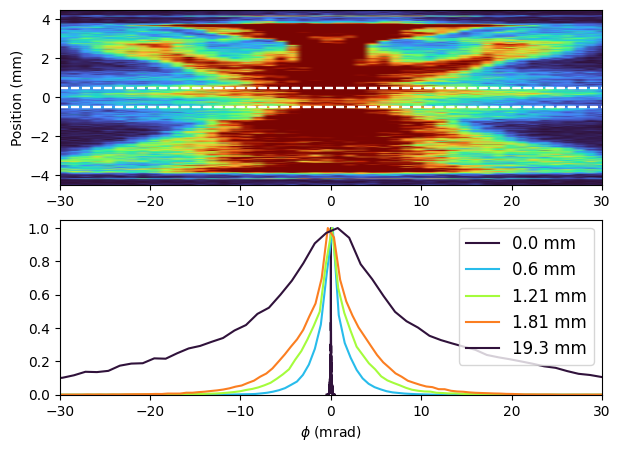

In [88]:
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(2,1,figsize=(7,5))

cmap = plt.get_cmap("turbo", 5)

for i in [0, 1, 2 , 3, -2]:

    x_mm = result["jvec"][i][0] * 1e3
    phi_mrad = result["jvec"][i][1] * 1e3
    
    phi_centers, phi_dist, x_centers, H, x_mask = phi_distribution_from_roi(
        x_mm, phi_mrad,
        x_roi_mm=(-.75, 0.75)
    )
    
    extent = [phi_centers.min(), phi_centers.max(), x_centers.min(), x_centers.max()]
    
    ax0.imshow(H, origin="lower", aspect="auto", extent=extent, cmap="turbo", clim = [H.min(), H.max()*0.1])
    ax0.axhline(-.5, ls="--", c="w")
    ax0.axhline( .5, ls="--", c="w")
    ax0.set_ylim(-4.5, 4.5)
    ax0.set_yticks([-4, -2, 0, 2, 4])
    ax0.set_xlim(-30,30)
    ax0.set_ylabel("Position (mm)")
    
    ax1.plot(phi_centers, phi_dist / phi_dist.max(), c = cmap(i), lw=1.5, label = f"{round(depth_mm[i], 2)} mm" )

for ax in [ax1]:
    ax.set_xlim(-30,30)
    ax.set_xticks([-30, -20,-10,0,10,20,30])
    ax.grid(False)
    ax.set_xlabel(r"$\phi$ (mrad)")
    ax.set_ylim(bottom = 0)
    ax.legend(fontsize = 12)

# moments VS propagation depth

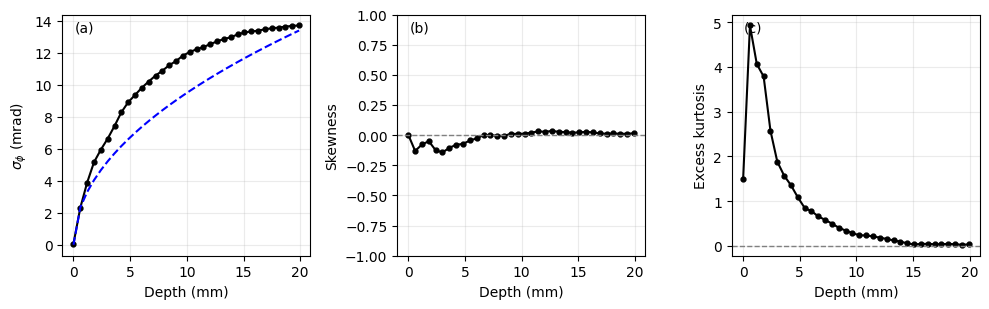

In [91]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10, 3.2), sharex=True)

plot_kw = dict(marker='o', ms=3.5, lw=1.5, c='k')

ax0.plot(df_syn["depth_mm"], df_syn["std_mrad"], **plot_kw)
ax0.plot(df_syn["depth_mm"], 3*df_syn["depth_mm"]**0.5, c = "b", ls = "--")

ax0.set_ylabel(r"$\sigma_\phi$ (mrad)")
ax0.set_xlabel("Depth (mm)")
ax0.text(0.05, 0.93, "(a)", transform=ax0.transAxes)
# ax0.set_xscale("log")
# ax0.set_yscale("log")

ax1.plot(df_syn["depth_mm"], df_syn["skew"], **plot_kw)
ax1.axhline(0, ls='--', lw=1, c='0.5')
ax1.set_ylabel("Skewness")
ax1.set_xlabel("Depth (mm)")
ax1.text(0.05, 0.93, "(b)", transform=ax1.transAxes)
ax1.set_ylim(-1, 1)

ax2.plot(df_syn["depth_mm"], df_syn["excess_kurtosis"], **plot_kw)
ax2.axhline(0, ls='--', lw=1, c='0.5')
ax2.set_ylabel("Excess kurtosis")
ax2.set_xlabel("Depth (mm)")
ax2.text(0.05, 0.93, "(c)", transform=ax2.transAxes)

for ax in (ax0, ax1, ax2):
    ax.grid(alpha=0.25)
